In [1]:
#General packages, powerlaw is vital for this analysis
import numpy as np
import numpy.ma as ma
from tqdm import tqdm
import random
import pandas as pd
import powerlaw
from astropy.time import Time

#Matplotlib packages
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib import rcParams
from matplotlib import transforms
from matplotlib.ticker import ScalarFormatter, MultipleLocator

#Scipy packages 
from scipy.optimize import curve_fit
from scipy.stats import chi2
import scipy.optimize as spopt

#Astropy packages
from astropy import units as u
from astropy.cosmology import Planck15 as cosmo

# #Figure settings
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

import frb_functions

In [2]:
def hyperflash_exposure_per_day():

    hf_l_exp_days = pd.read_csv("../observing_hours/hf_unique_time_combined_lband_per_day.csv", header=0, sep=',')
    display(hf_l_exp_days)

    return hf_l_exp_days

hf_l_exp_days = hyperflash_exposure_per_day()

,mjd_day,unique_hours
0,60338,4.734667
1,60339,7.126805
2,60340,9.469061
3,60342,9.537965
4,60343,6.692601
...,...,...
483,61137,2.740279
484,61138,2.740024
485,61141,2.739733
486,61142,2.738568


In [3]:
def hyperflash_nrt_exposure_per_day():

    hf_nrt_l_exp_days = pd.read_csv("../observing_hours/hf_nrt_unique_time_combined_lband_per_day.csv", header=0, sep=',')
    display(hf_nrt_l_exp_days)

    return hf_nrt_l_exp_days

hf_nrt_l_exp_days = hyperflash_nrt_exposure_per_day()

,mjd_day,unique_hours
0,60338,4.734667
1,60339,7.126805
2,60340,9.469061
3,60342,9.537965
4,60343,6.692601
...,...,...
501,61137,2.740279
502,61138,2.740024
503,61141,2.739733
504,61142,2.738568


In [4]:
hf_l_exp_days[hf_l_exp_days["mjd_day"].between(60586,60654)]["unique_hours"].sum()

176.9062699174974

In [5]:
def nancay(csv_file, mjd_limit=True):
    """
    Function to import the fluences for the NRT sample
    """

    nancay_df = pd.read_csv(csv_file, on_bad_lines='skip', header=0, sep=',')
    nancay_df = nancay_df.sort_values(by="MJD_at_peak")
    mjds = nancay_df['MJD_at_peak'].values
    print(f"The first burst by NRT was detected on {np.min(mjds):.3f}")
    print(f"The last burst by NRT was detected on {np.max(mjds):.3f}")

    if mjd_limit:
        #These dates are the entire campaign for now
        mjd_begin = 60337
        mjd_end = 60552
        nancay_df = nancay_df[nancay_df['MJD_at_peak'].between(mjd_begin, mjd_end)]

    # Drop subzero fluences
    nancay_df = nancay_df[nancay_df['fluence_Jyms'] >= 0]

    zero_fluences = nancay_df[nancay_df['fluence_Jyms'] < 0]['fluence_Jyms'].values
    if len(zero_fluences) > 0:
        print(f"Removed {len(zero_fluences)} negative fluences: {zero_fluences}")

    nrt_toa = nancay_df["MJD_at_peak"].values
    nrt_fluence = nancay_df["fluence_Jyms"].values

    return nrt_toa, nrt_fluence

nrt_toa, nrt_fluence = nancay(csv_file="../databases/NRT_burst_properties_Lband.csv",mjd_limit=False)

The first burst by NRT was detected on 60346.493
The last burst by NRT was detected on 60722.469


In [6]:
def fast_zhang_2024(csv_file):
    """
    Read in csv FAST .csv file  
    from: https://ui.adsabs.harvard.edu/abs/2025arXiv250714707Z/abstract
    host: https://doi.org/10.57760/sciencedb.Fastro.00030
    """

    #Read CSV normally (don't set index_col)
    fast_csv = pd.read_csv(csv_file, sep=",", header=0, na_values='NA', index_col=0)
    
    # Rename measurement columns only (keep BurstID and Date as-is)
    fast_csv = fast_csv.rename(columns={
        "MJD(topo@1.5GHz)": "MJD",
        "DM(pc/cc)": "DM",
        "DM_err(pc/cc)": "DMError",
        "Weff(ms)": "width",
        "Weff_err(ms)": "widtherror",
        "Flux(mJy)": "flux",
        "Flux_err(mJy)": "fluxerror",
        "Bandwidth(MHz)": "bandwidth",
        "Bandwidth_err(MHz)": "bandwidtherror",
        "Fluence(mJy ms)": "fluence_mJyms",
        "Fluence_err(mJy ms)": "fluenceerror",
        "Energy(erg)": "energy",
        "Energy_err(erg)": "energyerror",
        "Center_Freq.(MHz)": "feakfrequency",
        "Center_Freq_err(MHz)": "feakfrequencyerror"
    })
    
    # Filter by MJD
    #mjd_begin = 59869
    #mjd_end = 59910
    #fast_csv = fast_csv[fast_csv['MJD'].between(mjd_begin, mjd_end)]
    
    # Display dataframe
    display(fast_csv)
    
    # Return fluence and full dataframe (BurstID included)
    fluence = fast_csv['fluence_mJyms'].values / 1_000

    return fluence, fast_csv
    
fast_fluence_r147, fast_csv = fast_zhang_2024(csv_file="../databases/fast_zhang_2025/FRB20240114A_SuppTab2_saturation_tag.csv")  

,BurstID,Date,MJD,MJD(bary@inf freq.),DM,DMError,width,widtherror,flux,fluxerror,...,Upper_freq_err(MHz),Tsamp(s),Nchan,fluence_mJyms,fluenceerror,energy,energyerror,note,bestfit,saturation_tag
0,B00001,20240128,60337.238280,60337.234184,529.5,0.1,3.51,0.23,217.48,9.57,...,5.8,0.000197,4096,764.10,61.05,6.117930e+37,5.979520e+36,NaN,Gaussian,False
1,B00002,20240128,60337.240239,60337.236143,529.6,0.8,2.60,0.43,86.47,3.81,...,6.9,0.000197,4096,224.77,38.88,7.196810e+36,1.466040e+36,NaN,CDF,False
2,B00003,20240128,60337.241530,60337.237434,525.0,0.3,4.63,1.23,18.15,0.95,...,35.6,0.000197,4096,84.01,22.77,1.269590e+37,4.199310e+36,NaN,Gaussian,False
3,B00004,20240128,60337.243759,60337.239663,526.7,2,2.66,0.49,74.30,3.33,...,4.7,0.000197,4096,197.63,37.69,6.201740e+36,1.266920e+36,NaN,CDF,False
4,B00005,20240128,60337.243836,60337.239740,527.0,2.2,1.20,0.26,77.42,3.59,...,2.2,0.000197,4096,93.21,20.58,4.137900e+36,9.265410e+35,NaN,Gaussian,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11548,B11549,20240830,60551.711875,60551.718359,533.2,0.7,3.22,0.35,42.10,3.54,...,2.6,0.000049,4096,135.46,18.55,9.884280e+36,1.379980e+36,NaN,Gaussian,False
11549,B11550,20240830,60551.712392,60551.718876,529.3,0.5,2.55,0.52,17.94,1.55,...,14.0,0.000049,4096,45.80,10.09,9.357970e+36,2.120070e+36,NaN,Gaussian,False
11550,B11551,20240830,60551.712486,60551.718970,528.3,1.5,2.53,0.54,29.90,2.60,...,5.9,0.000049,4096,75.64,17.39,3.714680e+36,8.806030e+35,NaN,CDF,False
11551,B11552,20240830,60551.712593,60551.719077,533.2,0.2,5.73,0.39,63.96,5.95,...,9.5,0.000049,4096,366.41,42.07,5.303470e+37,6.313060e+36,NaN,CDF,False


In [7]:
# Function to calculate energy per Hz at a given redshift (z)
def isotropic_energies(fluences_jy_ms, dist_mpc=616, z=0.130287):
    
    # Convert fluence from Jy·ms to Jy·s
    fluence_jys = np.array(fluences_jy_ms) * 1e-3  # Jy·s
    
    # Convert the distance from megaparsec to cm
    dis = 1.0 * u.megaparsec
    megap_cm = dis.to(u.cm).value

    #mpc to cm
    distance_lum_cm = megap_cm*dist_mpc

    #Redshift correction, see Macquart and Eckers for the function
    red_cor = 1 / (1 + z)**2

    # calculate energy per Hz
    energy_specific = fluence_jys * 4*np.pi*(distance_lum_cm**2) * 1e-23 * red_cor

    # scale to GHz for erg
    energy_ghz_scaled = energy_specific * 1e9
    
    return energy_ghz_scaled

In [8]:
def energy_to_fluence(energies, distance=616,z=0.130287):
    """Convert isotropic energies to fluences"""
    "Needed for the inverse calculation for a secondary axis"
    # Convert distance from Mpc to cm
    dis = 1.0 * u.megaparsec
    megap_cm = dis.to(u.cm).value
    distance_lum_cm = megap_cm * distance

    # Apply redshift correction
    red_cor = 1 / (1 + z)**2

    # Calculate fluence in Jy ms
    fluence_jys = energies / (4 * np.pi * (distance_lum_cm**2) * 1e-23 * red_cor)
    fluences = fluence_jys * 1e3  # Convert from Jy s to Jy ms
    return fluences

In [9]:
def fluence_hyperflash_loader(csv_file, band="L", mjd_limit=False, telescope=None):

    fluence_df = pd.read_csv(csv_file, index_col=0)

    fluence_df = fluence_df[["id", "toa", "fluence", "bandwidth", "central frequency", "2bit-wb-tag"]].rename(columns={"central frequency": "cent_freq"})
    fluence_df = fluence_df.dropna(subset=["toa"])

    fluence_df["burst-index"] = fluence_df['id'].str.split('-').str[0].str[1:].astype(int)
    fluence_df["telescope"] = fluence_df['id'].str.split('-').str[1].astype(str)

    ##Method to filter on telescope: wb, tr, st, o8
    if telescope is not None:
        try:
            fluence_df = fluence_df[fluence_df["telescope"] == telescope]
        except KeyError:
            print("Warning: 'telescope' column not found. Skipping filter.")

    if mjd_limit ==True:
        mjd_begin = 60337
        mjd_end = 60552
        fluence_df = fluence_df[fluence_df['toa'].between(mjd_begin, mjd_end)]

    if band == "L":
        fluence_df = fluence_df[fluence_df["cent_freq"] > 1000]
    elif band == "P": 
        fluence_df = fluence_df[fluence_df["cent_freq"] < 1000]
        
    fluence_df = fluence_df.sort_values(by=['toa'])
    fluence_df = fluence_df.reset_index(drop=True)

    return fluence_df

full_hyperflash_db = fluence_hyperflash_loader(csv_file="../databases/FRB20240114A_HyperFlash_paper_table.csv", mjd_limit=False)

full_hyperflash_db_no_dupl = full_hyperflash_db.loc[full_hyperflash_db.groupby("burst-index")["fluence"].idxmax()]
toa_hf = full_hyperflash_db_no_dupl['toa'].values
fluence_hf = full_hyperflash_db_no_dupl['fluence'].values
display(full_hyperflash_db_no_dupl)

print(np.max(fluence_hf))

,id,toa,fluence,bandwidth,cent_freq,2bit-wb-tag,burst-index,telescope
0,B02-wb,60355.639527,16.66,128.0,1271.0,0.0,2,wb
1,B03-st,60357.339134,20.15,98.0,1381.0,0.0,3,st
2,B04-st,60357.433876,25.10,53.0,1381.0,0.0,4,st
3,B05-st,60361.542887,35.49,98.0,1381.0,0.0,5,st
4,B06-st,60366.341592,16.72,98.0,1381.0,0.0,6,st
...,...,...,...,...,...,...,...,...
205,B176-tr,60816.177709,7.27,128.0,1444.0,0.0,176,tr
206,B177-wb,60816.333009,23.81,128.0,1271.0,0.0,177,wb
208,B178-wb,60817.072561,28.74,128.0,1271.0,1.0,178,wb
207,B179-wb,60817.072561,21.07,128.0,1271.0,1.0,179,wb


3982.85


In [11]:
def energy_time(energies, timestamps, df_combined):
    """
    Plot cumulative energy (erg) vs MJD with observing time per day as background histogram.
    """
    def energy_to_fluence_single(energy):
        return energy_to_fluence([energy])[0]
            
    sort_idx = np.argsort(timestamps)
    timestamps = timestamps[sort_idx]
    energies = energies[sort_idx]
    cumulative_fluence = np.cumsum(energies)

    # Convert cumulative fluence to cumulative energy (erg)
    cumulative_energy = np.array([isotropic_energies([f])[0] for f in cumulative_fluence])

    fig, ax = plt.subplots(figsize=(14,5))

    # ------------------------------------------------------------------
    # Background histogram: unique L-band observing time per MJD day
    # ------------------------------------------------------------------
    ax_hist = ax.twinx()
    ax_hist.bar(df_combined["mjd_day"] + 0.5,
                df_combined["unique_hours"],
                width=1.0,
                color="#1b9e77",
                alpha=0.325,
                label="Observing time")
    ax_hist.set_ylabel("Observing time (h)", fontsize=25, labelpad=10)
    ax_hist.tick_params(axis='y', labelsize=22)
    ax_hist.set_ylim(0, 12)
    ax_hist.set_zorder(ax.get_zorder() - 1)
    ax_hist.yaxis.set_minor_locator(MultipleLocator(1))
    ax.set_facecolor("none")

    # ------------------------------------------------------------------
    # Cumulative energy curve
    # ------------------------------------------------------------------
    ax.step(timestamps, cumulative_energy, where='post', color='purple', label="HyperFlash", lw=3)
    ax.set_xlabel("Time (MJD)", fontsize=25)
    ax.set_ylabel("Cumulative energy (erg)", fontsize=25)
    ax.tick_params(labelsize=22)
    ax.tick_params(axis='x', pad=10)
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.grid(True)
    ax.set_xlim(60323, 61148)
    ax.xaxis.set_major_locator(MultipleLocator(100))
    ax.xaxis.set_minor_locator(MultipleLocator(25))
    ax.yaxis.set_minor_locator(MultipleLocator(0.5e42))
    ax.set_ylim(0, 6e42)

    # Force scientific notation on y-axis (secondary or primary)
    ax.yaxis.offsetText.set_fontsize(24)
    
    total_energy = 1.7e47 #erg
    total_radio_5 = total_energy * 1e-5
    ax.axhline(total_radio_5, color="#d95f02", linestyle='--', linewidth=2, label=r"$E_\mathrm{tot} \,|\ \epsilon_\mathrm{radio} = 10^{-5}$")

    # Spine + tick styling
    for a in [ax, ax_hist]:
        for spine in a.spines.values():
            spine.set_linewidth(2)
        a.tick_params(axis='y', which='major', direction='out', length=15, width=2)
        a.tick_params(axis='y', which='minor', direction='out', length=7.5, width=2)
        a.tick_params(axis='x', which='major', direction='out', length=15, width=2)
        a.tick_params(axis='x', which='minor', direction='out', length=7.5, width=2)

    # Combined legend
    handles, labels = ax.get_legend_handles_labels()
    handles_h, labels_h = ax_hist.get_legend_handles_labels()
    leg = ax.legend(handles + handles_h, labels + labels_h,
                loc='upper right', bbox_to_anchor=(1.0, 1.0),
                ncol=3, markerscale=2, fontsize=14)
    for lh in leg.legend_handles:
        lh.set_alpha(1)

    # save_name = "cumulative_energy_hf_v2"
    # plt.savefig(f"../plots/{save_name}.pdf", format = 'pdf', dpi=300, bbox_inches='tight')
    # plt.savefig(f"../plots/{save_name}.png", facecolor='white', transparent=False, \
    #             format = 'png',bbox_inches='tight', dpi=300)
    
    plt.show()

#energy_time(energies=fluence_hf, timestamps=toa_hf, df_combined=hf_l_exp_days)

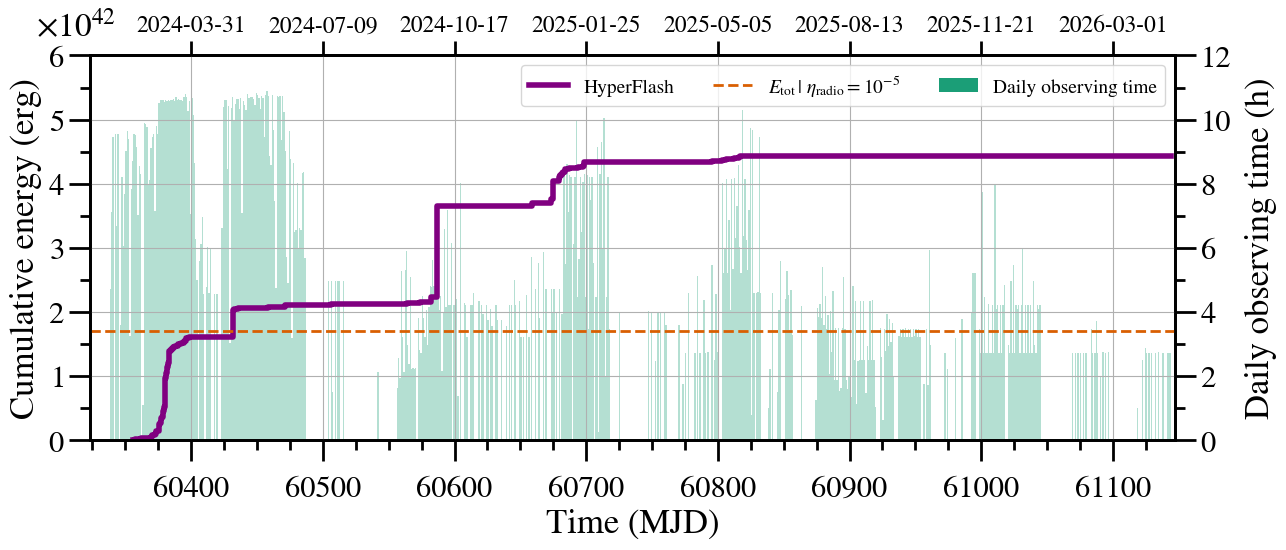

In [21]:
def energy_time(energies, timestamps, df_combined):
    """
    Plot cumulative energy (erg) vs MJD with observing time per day as background histogram.
    """
    def energy_to_fluence_single(energy):
        return energy_to_fluence([energy])[0]
            
    sort_idx = np.argsort(timestamps)
    timestamps = timestamps[sort_idx]
    energies = energies[sort_idx]
    cumulative_fluence = np.cumsum(energies)
    # Convert cumulative fluence to cumulative energy (erg)
    cumulative_energy = np.array([isotropic_energies([f])[0] for f in cumulative_fluence])

    # ── Extend flatline to last observed day ──────────────────────────────────
    last_mjd = df_combined["mjd_day"].max() + 1
    timestamps = np.append(timestamps, last_mjd)
    cumulative_energy = np.append(cumulative_energy, cumulative_energy[-1])
    # ─────────────────────────────────────────────────────────────────────────

    fig, ax = plt.subplots(figsize=(14, 5))

    # ------------------------------------------------------------------
    # Background histogram: unique L-band observing time per MJD day
    # ------------------------------------------------------------------
    ax_hist = ax.twinx()
    ax_hist.bar(df_combined["mjd_day"] + 0.5,
                df_combined["unique_hours"],
                width=1.0,
                color="#1b9e77",
                alpha=0.325,
                label="Daily observing time")
    ax_hist.set_ylabel("Daily observing time (h)", fontsize=25, labelpad=10)
    ax_hist.tick_params(axis='y', labelsize=22)
    ax_hist.set_ylim(0, 12)
    ax_hist.set_zorder(ax.get_zorder() - 1)
    ax_hist.yaxis.set_minor_locator(MultipleLocator(1))
    ax.set_facecolor("none")

    # ------------------------------------------------------------------
    # Cumulative energy curve
    # ------------------------------------------------------------------
    ax.step(timestamps, cumulative_energy, where='post', color='purple', label="HyperFlash", lw=4)
    ax.set_xlabel("Time (MJD)", fontsize=25)
    ax.set_ylabel("Cumulative energy (erg)", fontsize=25)
    ax.tick_params(labelsize=22)
    ax.tick_params(axis='x', pad=10)
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.grid(True)
    ax.set_xlim(60323, 61147)
    ax.xaxis.set_major_locator(MultipleLocator(100))
    ax.xaxis.set_minor_locator(MultipleLocator(25))
    ax.yaxis.set_minor_locator(MultipleLocator(0.5e42))
    ax.set_ylim(0, 6e42)

    ax.yaxis.offsetText.set_visible(False)
    ax.text(-0.05, 1.12, r"$\times 10^{42}$", transform=ax.transAxes, fontsize=24, va='top')

    total_energy = 1.7e47  # erg
    total_radio_5 = total_energy * 1e-5
    ax.axhline(total_radio_5, color="#d95f02", linestyle='--', linewidth=2,
               label=r"$E_\mathrm{tot} \,|\ \eta_\mathrm{radio} = 10^{-5}$")

    # ------------------------------------------------------------------
    # Secondary x-axis on top: ISO dates for a few selected MJD ticks
    # ------------------------------------------------------------------
    #date_mjds = [60400, 60600, 60800, 61000]  # 5 ticks across the range
    date_mjds = [60400, 60500,60600, 60700,60800,60900, 61000,61100]
    ax_top = ax.secondary_xaxis('top')
    ax_top.set_xticks(date_mjds)
    iso_labels = Time(date_mjds, format='mjd', scale='utc').to_value('isot', 'date')
    ax_top.set_xticklabels(iso_labels, rotation=0, ha='center', fontsize=17)
    ax_top.tick_params(axis='x', which='major', direction='out', length=10, width=2)
    # ------------------------------------------------------------------

    # Spine + tick styling
    for a in [ax, ax_hist]:
        for spine in a.spines.values():
            spine.set_linewidth(2)
        a.tick_params(axis='y', which='major', direction='out', length=15, width=2)
        a.tick_params(axis='y', which='minor', direction='out', length=7.5, width=2)
        a.tick_params(axis='x', which='major', direction='out', length=15, width=2)
        a.tick_params(axis='x', which='minor', direction='out', length=7.5, width=2)

    for spine in ax_top.spines.values():
        spine.set_linewidth(2)

    # Combined legend
    handles, labels = ax.get_legend_handles_labels()
    handles_h, labels_h = ax_hist.get_legend_handles_labels()
    leg = ax.legend(handles + handles_h, labels + labels_h,
                    loc='upper right', bbox_to_anchor=(1.0, 1.0),
                    ncol=3, markerscale=2, fontsize=14)
    for lh in leg.legend_handles:
        lh.set_alpha(1)

    save_name = "cumulative_energy_hf_v4"
    plt.savefig(f"../plots/{save_name}.pdf", format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f"../plots/{save_name}.png", facecolor='white', transparent=False,
                format='png', bbox_inches='tight', dpi=300)

    plt.show()
energy_time(energies=fluence_hf, timestamps=toa_hf, df_combined=hf_l_exp_days)

In [14]:
def energy_time(energies, timestamps, df_combined):
    """
    Plot cumulative energy (erg) vs MJD with cumulative observing time as a filled area,
    plus FAST and NRT cumulative energy curves.
    """
    sort_idx = np.argsort(timestamps)
    timestamps = timestamps[sort_idx]
    energies = energies[sort_idx]
    cumulative_fluence = np.cumsum(energies)
    cumulative_energy = np.array([isotropic_energies([f])[0] for f in cumulative_fluence])

    # ── Extend flatline to last observed day ─────────────────────────────────
    last_mjd = 61143
    timestamps = np.append(timestamps, last_mjd)
    cumulative_energy = np.append(cumulative_energy, cumulative_energy[-1])
    # ─────────────────────────────────────────────────────────────────────────

    fig, ax = plt.subplots(figsize=(14, 5))

    # ------------------------------------------------------------------
    # Cumulative observing time — filled area
    # ------------------------------------------------------------------
    df_combined = df_combined.sort_values("mjd_day")
    df_combined["cumulative_hours"] = df_combined["unique_hours"].cumsum()

    ax_hist = ax.twinx()
    ax_hist.fill_between(df_combined["mjd_day"] + 0.5,
                         df_combined["cumulative_hours"],
                         step='post',
                         color="#1b9e77",
                         alpha=0.25,
                         label="Cumulative observing time")
    ax_hist.step(df_combined["mjd_day"] + 0.5,
                 df_combined["cumulative_hours"],
                 where='post',
                 color="#1b9e77",
                 alpha=0.80,
                 lw=2,
                 label="_nolegend_")
    ax_hist.set_ylabel("HyperFlash observing time (h)", fontsize=23, labelpad=10)
    ax_hist.tick_params(axis='y', labelsize=22)
    ax_hist.set_ylim(0, 3000)
    ax_hist.set_zorder(ax.get_zorder() - 1)
    ax_hist.yaxis.set_minor_locator(MultipleLocator(250))
    ax.set_facecolor("none")

    # ------------------------------------------------------------------
    # Cumulative energy curve — HyperFlash
    # ------------------------------------------------------------------
    ax.step(timestamps, cumulative_energy, where='post', color='purple', label="HyperFlash", lw=4, zorder=3)

    # ------------------------------------------------------------------
    # Arrow pointing to the brightest burst
    # ------------------------------------------------------------------
    energy_diffs = np.diff(cumulative_energy)
    brightest_idx = np.argmax(energy_diffs)
    brightest_mjd = timestamps[brightest_idx]
    brightest_energy = cumulative_energy[brightest_idx + 1]  # top of the step
    
    ax.annotate(
        '',
        xy=(brightest_mjd, brightest_energy),
        xytext=(brightest_mjd, brightest_energy + 0.7e42),
        arrowprops=dict(
            arrowstyle='->',
            color='black',
            lw=2.5,
            mutation_scale=20,
        ),
        annotation_clip=False,
        zorder=5,
    )

    # ------------------------------------------------------------------
    # Cumulative energy curve — FAST
    # ------------------------------------------------------------------
    fast_fluence_jyms = fast_csv['fluence_mJyms'].values / 1_000
    fast_toa = fast_csv["MJD"].values
    sort_idx_fast = np.argsort(fast_toa)
    fast_toa = fast_toa[sort_idx_fast]
    fast_fluence_jyms = fast_fluence_jyms[sort_idx_fast]
    cumulative_fluence_fast = np.cumsum(fast_fluence_jyms)
    cumulative_energy_fast = np.array([isotropic_energies([f])[0] for f in cumulative_fluence_fast])
    ax.step(fast_toa, cumulative_energy_fast, where='post', color='black', label="FAST", lw=4, zorder=3)

    # ------------------------------------------------------------------
    # Cumulative energy curve — NRT
    # ------------------------------------------------------------------
    sort_idx_nrt = np.argsort(nrt_toa)
    nrt_toa_sorted = nrt_toa[sort_idx_nrt]
    nrt_fluence_sorted = nrt_fluence[sort_idx_nrt]
    cumulative_fluence_nrt = np.cumsum(nrt_fluence_sorted)
    cumulative_energy_nrt = np.array([isotropic_energies([f])[0] for f in cumulative_fluence_nrt])
    ax.step(nrt_toa_sorted, cumulative_energy_nrt, where='post', color='red', label="NRT", lw=4, zorder=3)

    # ------------------------------------------------------------------
    ax.set_xlabel("Time (MJD)", fontsize=25)
    ax.set_ylabel("Cumulative energy (erg)", fontsize=25)
    ax.tick_params(labelsize=22)
    ax.tick_params(axis='x', pad=10)
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.grid(True)
    ax.set_xlim(60323, 61148)
    ax.xaxis.set_major_locator(MultipleLocator(100))
    ax.xaxis.set_minor_locator(MultipleLocator(25))
    ax.yaxis.set_minor_locator(MultipleLocator(0.5e42))
    ax.set_ylim(0, 6e42)

    ax.yaxis.offsetText.set_visible(False)
    ax.text(-0.05, 1.12, r"$\times 10^{42}$", transform=ax.transAxes, fontsize=24, va='top')

    total_energy = 1.7e47  # erg
    total_radio_5 = total_energy * 1e-5
    ax.axhline(total_radio_5, color="#d95f02", linestyle='--', linewidth=2,
               label=r"$E_\mathrm{tot} \,|\ \epsilon_\mathrm{radio} = 10^{-5}$")

    # ------------------------------------------------------------------
    # Secondary x-axis on top: ISO dates for a few selected MJD ticks
    # ------------------------------------------------------------------
    date_mjds = [60400, 60500, 60600, 60700, 60800, 60900, 61000, 61100]
    ax_top = ax.secondary_xaxis('top')
    ax_top.set_xticks(date_mjds)
    iso_labels = Time(date_mjds, format='mjd', scale='utc').to_value('isot', 'date')
    ax_top.set_xticklabels(iso_labels, rotation=0, ha='center', fontsize=17)
    ax_top.tick_params(axis='x', which='major', direction='out', length=10, width=2)
    # ------------------------------------------------------------------

    # Spine + tick styling
    for a in [ax, ax_hist]:
        for spine in a.spines.values():
            spine.set_linewidth(2)
        a.tick_params(axis='y', which='major', direction='out', length=15, width=2)
        a.tick_params(axis='y', which='minor', direction='out', length=7.5, width=2)
        a.tick_params(axis='x', which='major', direction='out', length=15, width=2)
        a.tick_params(axis='x', which='minor', direction='out', length=7.5, width=2)

    for spine in ax_top.spines.values():
        spine.set_linewidth(2)

    # Combined legend
    handles, labels = ax.get_legend_handles_labels()
    handles_h, labels_h = ax_hist.get_legend_handles_labels()

    all_handles = handles + handles_h
    all_labels  = labels  + labels_h

    leg = ax.legend(all_handles, all_labels,
                    loc='upper left', bbox_to_anchor=(0.0, 1.0),
                    ncol=2, markerscale=2, fontsize=14)
    for lh in leg.legend_handles:
        lh.set_alpha(1)

    save_name = "cumulative_energy_hf_fast_nrt_v3"
    plt.savefig(f"../plots/{save_name}.pdf", format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f"../plots/{save_name}.png", facecolor='white', transparent=False,
                format='png', bbox_inches='tight', dpi=300)

    brightest_hf = isotropic_energies([np.max(energies)])[0]
    
    # How many FAST bursts (sorted by energy ascending) needed to match STROOP
    fast_energies = np.array([isotropic_energies([f])[0] for f in fast_fluence_jyms])
    fast_energies_sorted = np.sort(fast_energies)  # ascending (weakest first)
    fast_cumsum = np.cumsum(fast_energies_sorted)
    n_fast_needed = np.searchsorted(fast_cumsum, brightest_hf) + 1

    print(f"Total energy for HyperFlash : {cumulative_energy[-1]:.2e} erg and total bursts in sample: {len(energies)}")
    print(f"Total energy for FAST       : {cumulative_energy_fast[-1]:.2e} erg and total bursts in sample: {len(fast_fluence_jyms)}")
    print(f"Total energy for NRT        : {cumulative_energy_nrt[-1]:.2e} erg and total bursts in sample: {len(nrt_fluence_sorted)}")
    print(f"Energy of the STROOP        : {brightest_hf:.2e} erg")
    print(f"FAST bursts needed to match STROOP (weakest first) : {n_fast_needed}")
    plt.show()

#energy_time(energies=fluence_hf, timestamps=toa_hf, df_combined=hf_nrt_l_exp_days)

Total energy for HyperFlash : 4.44e+42 erg and total bursts in sample: 174
Total energy for FAST       : 2.34e+42 erg and total bursts in sample: 11553
Total energy for NRT        : 4.76e+41 erg and total bursts in sample: 673
Energy of the STROOP        : 1.42e+42 erg
FAST bursts needed to match STROOP (weakest first) : 10951


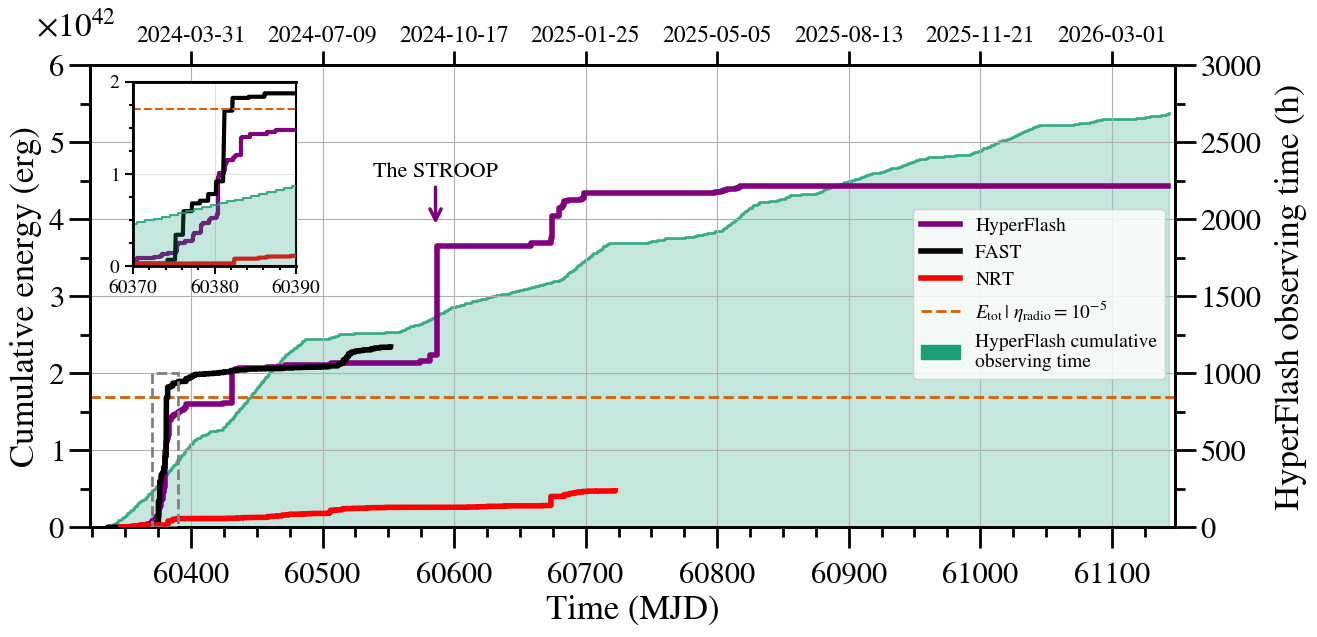

In [24]:
def energy_time_inset(energies, timestamps, df_combined):
    """
    Plot cumulative energy (erg) vs MJD with cumulative observing time as a filled area,
    plus FAST and NRT cumulative energy curves.
    Includes a zoom inset on the early high-burst-rate period (~MJD 60323-60395).
    """
    sort_idx = np.argsort(timestamps)
    timestamps = timestamps[sort_idx]
    energies = energies[sort_idx]
    cumulative_fluence = np.cumsum(energies)
    cumulative_energy = np.array([isotropic_energies([f])[0] for f in cumulative_fluence])

    # ── Extend flatline to last observed day ─────────────────────────────────
    last_mjd = 61143
    timestamps = np.append(timestamps, last_mjd)
    cumulative_energy = np.append(cumulative_energy, cumulative_energy[-1])
    # ─────────────────────────────────────────────────────────────────────────

    fig, ax = plt.subplots(figsize=(14, 6))  # ~15% taller

    # ------------------------------------------------------------------
    # Cumulative observing time — filled area
    # ------------------------------------------------------------------
    df_combined = df_combined.sort_values("mjd_day")
    df_combined["cumulative_hours"] = df_combined["unique_hours"].cumsum()

    ax_hist = ax.twinx()
    ax_hist.fill_between(df_combined["mjd_day"] + 0.5,
                         df_combined["cumulative_hours"],
                         step='post',
                         color="#1b9e77",
                         alpha=0.25,
                         label="HyperFlash cumulative" + "\n" + "observing time")
    ax_hist.step(df_combined["mjd_day"] + 0.5,
                 df_combined["cumulative_hours"],
                 where='post',
                 color="#1b9e77",
                 alpha=0.80,
                 lw=2,
                 label="_nolegend_")
    ax_hist.set_ylabel("HyperFlash observing time (h)", fontsize=25, labelpad=10)
    ax_hist.tick_params(axis='y', labelsize=22)
    ax_hist.set_ylim(0, 3000)
    ax_hist.set_zorder(ax.get_zorder() - 1)
    ax_hist.yaxis.set_minor_locator(MultipleLocator(250))
    ax.set_facecolor("none")

    # ------------------------------------------------------------------
    # Cumulative energy curve — HyperFlash
    # ------------------------------------------------------------------
    ax.step(timestamps, cumulative_energy, where='post', color='purple', label="HyperFlash", lw=4, zorder=3)

    # ------------------------------------------------------------------
    # Cumulative energy curve — FAST
    # ------------------------------------------------------------------
    fast_fluence_jyms = fast_csv['fluence_mJyms'].values / 1_000
    fast_toa = fast_csv["MJD"].values
    sort_idx_fast = np.argsort(fast_toa)
    fast_toa = fast_toa[sort_idx_fast]
    fast_fluence_jyms = fast_fluence_jyms[sort_idx_fast]
    cumulative_fluence_fast = np.cumsum(fast_fluence_jyms)
    cumulative_energy_fast = np.array([isotropic_energies([f])[0] for f in cumulative_fluence_fast])
    ax.step(fast_toa, cumulative_energy_fast, where='post', color='black', label="FAST", lw=4, zorder=3)

    # ------------------------------------------------------------------
    # Cumulative energy curve — NRT
    # ------------------------------------------------------------------
    sort_idx_nrt = np.argsort(nrt_toa)
    nrt_toa_sorted = nrt_toa[sort_idx_nrt]
    nrt_fluence_sorted = nrt_fluence[sort_idx_nrt]
    cumulative_fluence_nrt = np.cumsum(nrt_fluence_sorted)
    cumulative_energy_nrt = np.array([isotropic_energies([f])[0] for f in cumulative_fluence_nrt])
    ax.step(nrt_toa_sorted, cumulative_energy_nrt, where='post', color='red', label="NRT", lw=4, zorder=3)

    # ------------------------------------------------------------------
    ax.set_xlabel("Time (MJD)", fontsize=25)
    ax.set_ylabel("Cumulative energy (erg)", fontsize=25)
    ax.tick_params(labelsize=22)
    ax.tick_params(axis='x', pad=10)
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.grid(True)
    ax.set_xlim(60323, 61148)
    ax.xaxis.set_major_locator(MultipleLocator(100))
    ax.xaxis.set_minor_locator(MultipleLocator(25))
    ax.yaxis.set_minor_locator(MultipleLocator(0.5e42))
    ax.set_ylim(0, 6e42)

    ax.yaxis.offsetText.set_visible(False)
    ax.text(-0.05, 1.12, r"$\times 10^{42}$", transform=ax.transAxes, fontsize=24, va='top')

    total_energy = 1.7e47  # erg
    total_radio_5 = total_energy * 1e-5
    ax.axhline(total_radio_5, color="#d95f02", linestyle='--', linewidth=2,
               label=r"$E_\mathrm{tot} \,|\ \eta_\mathrm{radio} = 10^{-5}$")

    # ------------------------------------------------------------------
    # Secondary x-axis on top: ISO dates for a few selected MJD ticks
    # ------------------------------------------------------------------
    date_mjds = [60400, 60500, 60600, 60700, 60800, 60900, 61000, 61100]
    ax_top = ax.secondary_xaxis('top')
    ax_top.set_xticks(date_mjds)
    iso_labels = Time(date_mjds, format='mjd', scale='utc').to_value('isot', 'date')
    ax_top.set_xticklabels(iso_labels, rotation=0, ha='center', fontsize=17)
    ax_top.tick_params(axis='x', which='major', direction='out', length=10, width=2)

     # ------------------------------------------------------------------
    # Inset — zoom on early burst storm (~MJD 60323–60395)
    # ------------------------------------------------------------------
    # Position: [left, bottom, width, height] in axes-fraction coordinates
    # Placed in the middle of the main axes where curves are flat
    axins = ax.inset_axes([0.04, 0.565, 0.15, 0.40])

    inset_xlim = (60370, 60390)
    inset_ylim = (0, 2e42)

    ax_ins_hist = axins.twinx()
    ax_ins_hist.fill_between(df_combined["mjd_day"] + 0.5,
                             df_combined["cumulative_hours"],
                             step='post',
                             color="#1b9e77",
                             alpha=0.25)
    ax_ins_hist.step(df_combined["mjd_day"] + 0.5,
                     df_combined["cumulative_hours"],
                     where='post',
                     color="#1b9e77",
                     alpha=0.80,
                     lw=1.5)
    ax_ins_hist.set_ylim(0, 1000)
    ax_ins_hist.set_zorder(axins.get_zorder() - 1)
    ax_ins_hist.tick_params(axis='y', which='both', right=False, labelright=False)
    ax_ins_hist.spines['right'].set_visible(False)
    axins.set_facecolor("none")

    axins.step(timestamps, cumulative_energy, where='post', color='purple', lw=3, zorder=3)
    axins.step(fast_toa, cumulative_energy_fast, where='post', color='black', lw=3, zorder=3)
    axins.step(nrt_toa_sorted, cumulative_energy_nrt, where='post', color='red', lw=3, zorder=3)

    # Orange dashed reference line
    axins.axhline(total_radio_5, color="#d95f02", linestyle='--', linewidth=1.5, zorder=4)

    axins.set_xlim(*inset_xlim)
    axins.set_ylim(*inset_ylim)
    ax_ins_hist.set_xlim(*inset_xlim)

    axins.xaxis.set_major_locator(MultipleLocator(10))
    axins.xaxis.set_minor_locator(MultipleLocator(2))
    axins.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    #axins.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    axins.yaxis.set_major_locator(MultipleLocator(1e42))
    axins.yaxis.set_minor_locator(MultipleLocator(0.25e42))
    axins.tick_params(labelsize=14)
    axins.tick_params(axis='x', which='major', direction='out', length=6, width=1.5)
    axins.tick_params(axis='x', which='minor', direction='out', length=3, width=1.5)
    axins.tick_params(axis='y', which='major', direction='out', length=6, width=1.5)
    axins.tick_params(axis='y', which='minor', direction='out', length=3, width=1.5)
    axins.yaxis.offsetText.set_visible(False)
    axins.set_facecolor("white")
    axins.grid(True, alpha=0.4)

    for spine in axins.spines.values():
        spine.set_linewidth(1.5)

    # Rectangle on main axes marking the inset region
    ax.add_patch(plt.Rectangle((inset_xlim[0], inset_ylim[0]),
                                inset_xlim[1] - inset_xlim[0],
                                inset_ylim[1] - inset_ylim[0],
                                linewidth=2.0, edgecolor='gray',
                                facecolor='none', linestyle='--',
                                zorder=4, transform=ax.transData))

    # Arrow pointing to the STROOP event
    energy_diffs = np.diff(cumulative_energy)
    brightest_idx = np.argmax(energy_diffs)
    brightest_mjd = timestamps[brightest_idx] + 4
    brightest_energy = cumulative_energy[brightest_idx + 2]  # top of the step
    
    ax.annotate(
        'The STROOP',
        xy=(brightest_mjd, brightest_energy + 0.25e42),
        xytext=(brightest_mjd, brightest_energy + 0.9e42),
        arrowprops=dict(
            arrowstyle='->',
            color='purple',
            lw=2.5,
            mutation_scale=20,
        ),
        ha='center',
        fontsize=16,
        annotation_clip=False,
        zorder=5,
    )
    
    # ------------------------------------------------------------------
    # Spine + tick styling
    # ------------------------------------------------------------------
    for a in [ax, ax_hist,ax_ins_hist]:
        for spine in a.spines.values():
            spine.set_linewidth(2)
            
        a.tick_params(axis='y', which='major', direction='out', length=15, width=2)
        a.tick_params(axis='y', which='minor', direction='out', length=7.5, width=2)
        a.tick_params(axis='x', which='major', direction='out', length=15, width=2)
        a.tick_params(axis='x', which='minor', direction='out', length=7.5, width=2)

    for spine in ax_top.spines.values():
        spine.set_linewidth(2)

    # ------------------------------------------------------------------
    # Combined legend — moved to centre-right to free up upper-left
    # ------------------------------------------------------------------
    handles, labels = ax.get_legend_handles_labels()
    handles_h, labels_h = ax_hist.get_legend_handles_labels()

    all_handles = handles + handles_h
    all_labels  = labels  + labels_h

    leg = ax.legend(all_handles, all_labels,
                    loc='center right', bbox_to_anchor=(1.0, 0.505),
                    ncol=1, markerscale=2, fontsize=14)
    for lh in leg.legend_handles:
        lh.set_alpha(1)

    save_name = "cumulative_energy_hf_fast_nrt_inset_v3"
    plt.savefig(f"../plots/{save_name}.pdf", format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f"../plots/{save_name}.png", facecolor='white', transparent=False,
                format='png', bbox_inches='tight', dpi=300)

    brightest_hf = isotropic_energies([np.max(energies)])[0]

    fast_energies = np.array([isotropic_energies([f])[0] for f in fast_fluence_jyms])
    fast_energies_sorted = np.sort(fast_energies)
    fast_cumsum = np.cumsum(fast_energies_sorted)
    n_fast_needed = np.searchsorted(fast_cumsum, brightest_hf) + 1

    print(f"Total energy for HyperFlash : {cumulative_energy[-1]:.2e} erg and total bursts in sample: {len(energies)}")
    print(f"Total energy for FAST       : {cumulative_energy_fast[-1]:.2e} erg and total bursts in sample: {len(fast_fluence_jyms)}")
    print(f"Total energy for NRT        : {cumulative_energy_nrt[-1]:.2e} erg and total bursts in sample: {len(nrt_fluence_sorted)}")
    print(f"Energy of the STROOP        : {brightest_hf:.2e} erg")
    print(f"FAST bursts needed to match STROOP (weakest first) : {n_fast_needed}")
    plt.show()

energy_time_inset(energies=fluence_hf, timestamps=toa_hf, df_combined=hf_nrt_l_exp_days)

In [63]:
def wait_exposure_time():

    hf_l_wait_exp_time = pd.read_csv("../observing_hours/exposure_wait_time_hf.csv", header=0, sep=',')
    display(hf_l_wait_exp_time.sort_values("exposure_until_next_h").reset_index(drop=True))

    return hf_l_wait_exp_time

hf_l_wait_exp_time = wait_exposure_time()

,id,toa_utc,fluence,bandwidth,cent_freq,2bit-wb-tag,burst-index,telescope,toa_start,toa_end,exposure_since_previous_h,exposure_until_next_h
0,B179-wb,60817.071283,21.07,128.0,1271.0,1.0,179,wb,60816.331785,60817.071283,1.083189,6.932532e-08
1,B67-o8,60380.526961,24.11,128.0,1424.0,0.0,67,o8,60380.470449,60380.526961,1.356293,3.750203e-06
2,B63-o8,60380.452140,194.56,128.0,1424.0,0.0,63,o8,60380.444775,60380.452140,0.176772,1.404493e-05
3,B109-st,60387.367174,11.55,98.0,1381.0,0.0,109,st,60386.567614,60387.367174,5.908733,5.400233e-05
4,B51-st,60379.269508,16.72,98.0,1381.0,0.0,51,st,60379.260217,60379.269508,0.222995,1.642367e-02
...,...,...,...,...,...,...,...,...,...,...,...,...
169,B131-st,60458.074220,22.40,98.0,1381.0,0.0,131,st,60453.092095,60458.074220,52.098588,1.242126e+02
170,B137-wb,60586.952999,3982.85,128.0,1271.0,0.0,137,wb,60581.872510,60586.952999,27.317258,1.724546e+02
171,B129-wb,60436.095710,25.15,128.0,1271.0,1.0,129,wb,60435.328066,60436.095710,5.125423,1.773347e+02
172,B163-tr,60698.538428,184.49,128.0,1444.0,0.0,163,tr,60697.689412,60698.538428,5.598795,1.816881e+02


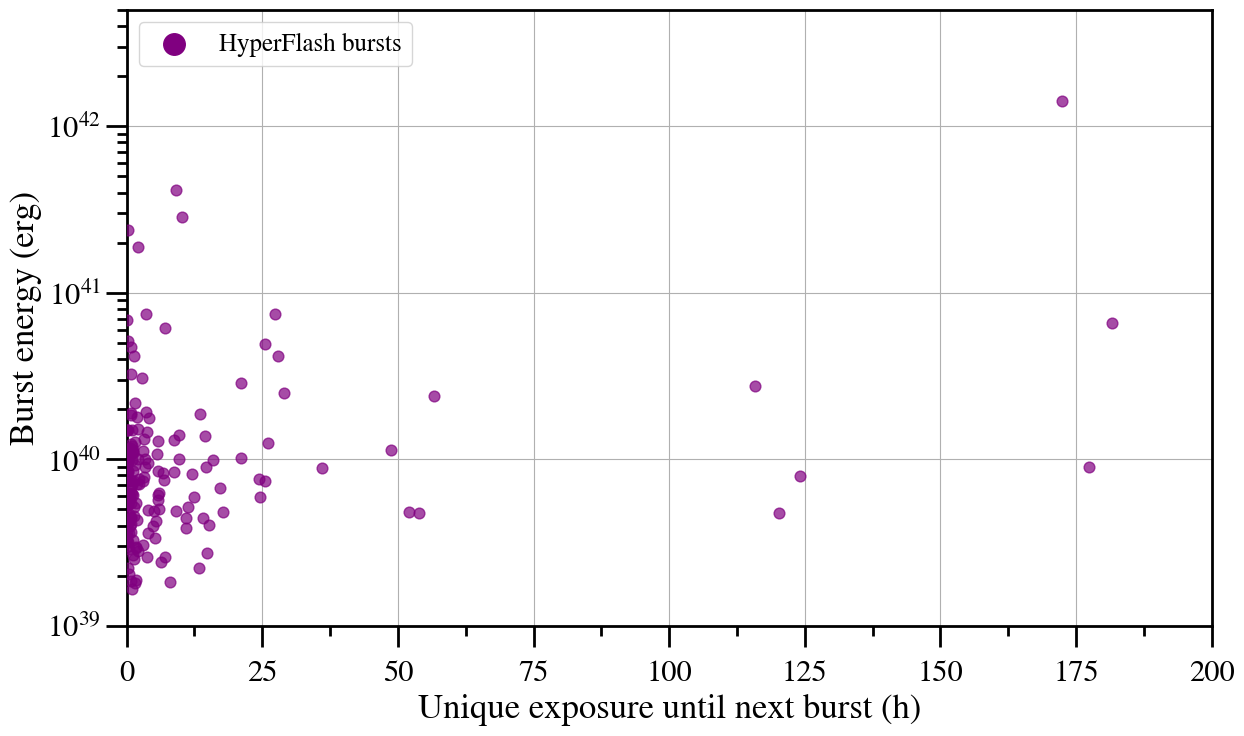

In [65]:
def wait_exposure_time(burst_db):
    """
    Scatter plot of burst energy (erg) vs unique exposure time until next burst.
    """
    # ------------------------------------------------------------------
    # Step 1: Remove NaN rows (last burst has no next burst)
    # ------------------------------------------------------------------
    df = burst_db.dropna(subset=["exposure_until_next_h"]).copy()

    # ------------------------------------------------------------------
    # Step 2: Convert fluence to energy (erg)
    # ------------------------------------------------------------------
    energies = np.array([isotropic_energies([f])[0] for f in df["fluence"].values])

    fig, ax = plt.subplots(figsize=(14, 8))

    # ------------------------------------------------------------------
    # Step 3: Scatter plot
    # ------------------------------------------------------------------
    ax.scatter(df["exposure_until_next_h"], energies,
               color="purple", alpha=0.7, s=60, zorder=3, label="HyperFlash bursts")

    ax.set_xlabel("Unique exposure until next burst (h)", fontsize=25)
    ax.set_ylabel("Burst energy (erg)", fontsize=25)
    ax.tick_params(labelsize=22)
    ax.tick_params(axis='x', pad=10)
    ax.set_yscale('log')
    ax.set_ylim(1e39, 5e42)
    ax.set_xlim(0, 200)
    ax.grid(True)

    ax.xaxis.set_major_locator(MultipleLocator(25))
    ax.xaxis.set_minor_locator(MultipleLocator(12.5))

    # Spine + tick styling
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.tick_params(axis='both', which='major', direction='out', length=15, width=2)
    ax.tick_params(axis='both', which='minor', direction='out', length=7.5, width=2)

    # Legend
    leg = ax.legend(loc='upper left', markerscale=2, fontsize=18)
    for lh in leg.legend_handles:
        lh.set_alpha(1)

    save_name = "wait_exposure_scatter_v1"
    plt.savefig(f"../plots/{save_name}.pdf", format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f"../plots/{save_name}.png", facecolor='white', transparent=False,
                format='png', bbox_inches='tight', dpi=300)

    plt.show()

wait_exposure_time(burst_db=hf_l_wait_exp_time)

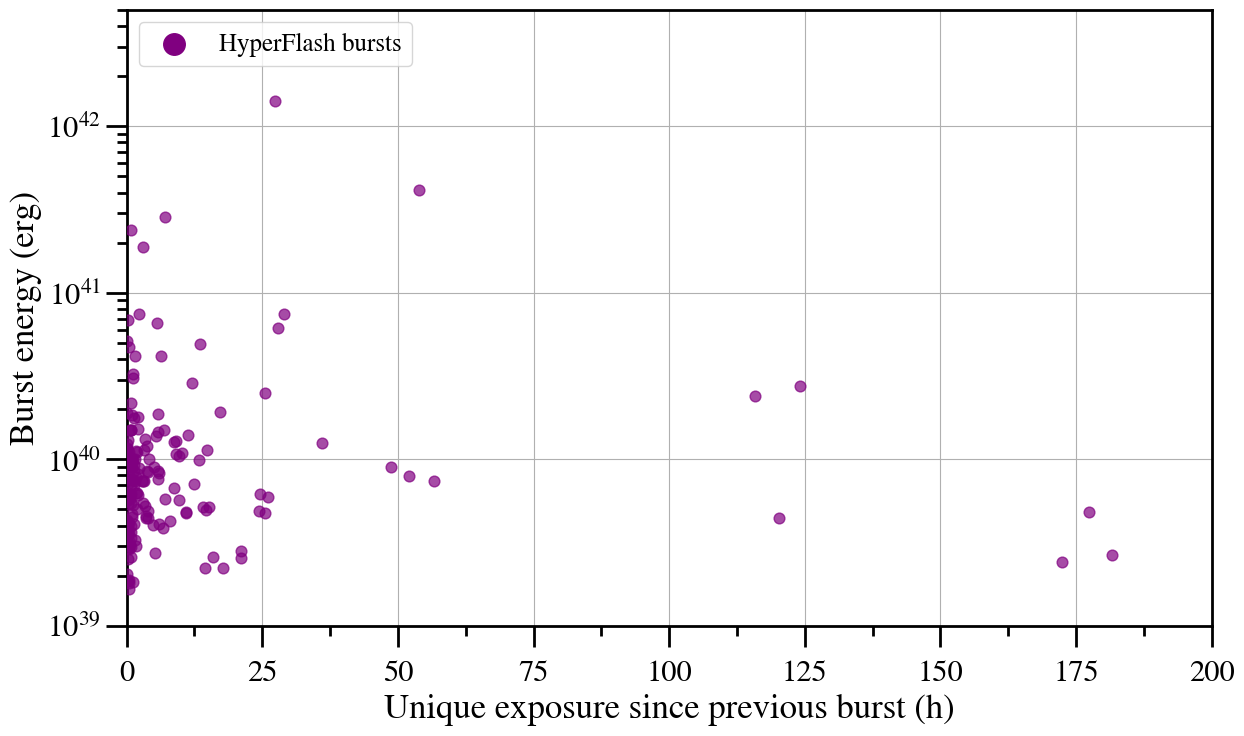

In [66]:
def wait_exposure_time(burst_db):
    """
    Scatter plot of burst energy (erg) vs unique exposure time until next burst.
    """
    # ------------------------------------------------------------------
    # Step 1: Remove NaN rows (last burst has no next burst)
    # ------------------------------------------------------------------
    df = burst_db.dropna(subset=["exposure_since_previous_h"]).copy()

    # ------------------------------------------------------------------
    # Step 2: Convert fluence to energy (erg)
    # ------------------------------------------------------------------
    energies = np.array([isotropic_energies([f])[0] for f in df["fluence"].values])

    fig, ax = plt.subplots(figsize=(14, 8))

    # ------------------------------------------------------------------
    # Step 3: Scatter plot
    # ------------------------------------------------------------------
    ax.scatter(df["exposure_since_previous_h"], energies,
               color="purple", alpha=0.7, s=60, zorder=3, label="HyperFlash bursts")

    ax.set_xlabel("Unique exposure since previous burst (h)", fontsize=25)
    ax.set_ylabel("Burst energy (erg)", fontsize=25)
    ax.tick_params(labelsize=22)
    ax.tick_params(axis='x', pad=10)
    ax.set_yscale('log')
    ax.set_ylim(1e39, 5e42)
    ax.set_xlim(0, 200)
    ax.grid(True)

    ax.xaxis.set_major_locator(MultipleLocator(25))
    ax.xaxis.set_minor_locator(MultipleLocator(12.5))

    # Spine + tick styling
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.tick_params(axis='both', which='major', direction='out', length=15, width=2)
    ax.tick_params(axis='both', which='minor', direction='out', length=7.5, width=2)

    # Legend
    leg = ax.legend(loc='upper left', markerscale=2, fontsize=18)
    for lh in leg.legend_handles:
        lh.set_alpha(1)

    save_name = "wait_exposure_previous_scatter_v1"
    plt.savefig(f"../plots/{save_name}.pdf", format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f"../plots/{save_name}.png", facecolor='white', transparent=False,
                format='png', bbox_inches='tight', dpi=300)

    plt.show()

wait_exposure_time(burst_db=hf_l_wait_exp_time)